In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Parameter
n_rows = 200  # jumlah baris data
start_date = datetime(2023, 5, 1)
categories = ["Elektronik", "Electronics", "elektronik", "Fashion", "Fesyen"]
statuses = ["paid", "pending", "cancelled"]
emails = ["@mail.com", "@gmail.com", "@yahoo.com", ""]

data = []
for i in range(5001, 5001 + n_rows):
    cust_id = f"C{str(random.randint(1, 50)).zfill(3)}"
    prod_id = f"P{str(random.randint(1, 30)).zfill(3)}" if random.random() > 0.05 else ""  # 5% missing

    # tanggal (ada invalid & salah format)
    if random.random() < 0.05:
        tanggal = "2023-02-31"
    elif random.random() < 0.05:
        tanggal = (start_date + timedelta(days=random.randint(0, 30))).strftime("%d/%m/%Y")
    else:
        tanggal = (start_date + timedelta(days=random.randint(0, 30))).strftime("%Y-%m-%d")

    jumlah = random.choice([random.randint(1, 5), -1, 0]) if random.random() < 0.1 else random.randint(1, 5)
    harga = random.choice([0, 99999999, random.randint(100, 1_000_000)]) if random.random() < 0.1 else random.randint(100, 1_000_000)

    if random.random() < 0.1:
        email = f"user{i}mail.com"
    elif random.random() < 0.05:
        email = ""
    else:
        email = f"user{i}{random.choice(emails)}"

    kode_pos = str(random.randint(10000, 99999)) if random.random() > 0.1 else random.choice(["4012a", ""])
    status = random.choice(statuses)
    kategori = random.choice(categories)

    data.append([i, cust_id, prod_id, tanggal, jumlah, harga, email, kode_pos, status, kategori])

# Buat DataFrame
df = pd.DataFrame(data, columns=["order_id","customer_id","product_id","tanggal","jumlah","harga","email","kode_pos","status","kategori"])

# Tambahkan duplikat
duplicates = df.sample(5)
df = pd.concat([df, duplicates], ignore_index=True)

# Simpan CSV
df.to_csv("assessment_orders_large.csv", index=False)
print("✅ Dataset berhasil dibuat: assessment_orders_large.csv")

✅ Dataset berhasil dibuat: assessment_orders_large.csv


In [ ]:
df

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,Fesyen
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,Fesyen
3,5004,C010,P006,2023-05-12,1,834845,user5004,,pending,Fashion
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,Fesyen
...,...,...,...,...,...,...,...,...,...,...
200,5168,C007,P024,2023-05-24,3,289014,user5168@yahoo.com,39933,pending,Electronics
201,5024,C029,P010,2023-05-14,2,717844,user5024,16189,pending,elektronik
202,5200,C015,P030,2023-05-20,5,229641,user5200@gmail.com,68844,pending,Elektronik
203,5042,C034,P007,2023-05-04,1,76954,user5042@mail.com,72461,cancelled,Electronics


In [ ]:
total_record = len(df)
missing_value = df.isna().sum()
duplikat = df['order_id'].duplicated().sum()


In [ ]:
missing_value = df.isna().sum()
missing_value

,0
order_id,0
customer_id,0
product_id,0
tanggal,0
jumlah,0
harga,0
email,0
kode_pos,0
status,0
kategori,0


In [ ]:
df['order_id'].duplicated()

,order_id
0,False
1,False
2,False
3,False
4,False
...,...
200,True
201,True
202,True
203,True


In [ ]:
invalid_jumlah = len(df[df['jumlah'] <= 0])
invalid_jumlah

12

In [ ]:
df.loc[df['jumlah'] <= 0]

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,Fesyen
7,5008,C008,P026,2023-05-04,0,121889,user5008@yahoo.com,50172,paid,Electronics
18,5019,C035,P018,2023-05-07,-1,938130,user5019@yahoo.com,76594,paid,elektronik
35,5036,C007,P011,2023-05-05,-1,669991,user5036@yahoo.com,20278,pending,Fesyen
82,5083,C007,P026,2023-05-19,-1,652917,user5083@mail.com,77602,pending,Fesyen
103,5104,C022,P019,2023-05-11,-1,513996,user5104mail.com,47186,paid,Fesyen
108,5109,C028,,2023-05-30,0,99999999,user5109,59523,cancelled,elektronik
122,5123,C028,P002,2023-02-31,-1,149671,user5123@gmail.com,46535,pending,Elektronik
125,5126,C016,P020,2023-05-26,0,799564,user5126,20251,pending,Fashion
152,5153,C022,,2023-05-25,-1,376633,user5153mail.com,91874,pending,Fashion


In [ ]:
invalid_harga = len(df.loc[(df['harga'] <= 0) | (df['harga']>= 10000000)])
invalid_harga


10

In [ ]:
df.loc[(df['harga'] <= 0) | (df['harga']>= 10000000)]

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
10,5011,C024,P002,2023-05-06,3,0,user5011@mail.com,,paid,Elektronik
40,5041,C019,P029,2023-05-27,1,99999999,user5041,,cancelled,Fesyen
50,5051,C002,P013,2023-05-23,5,99999999,user5051@gmail.com,86891,cancelled,Fashion
60,5061,C014,P018,2023-05-08,5,99999999,user5061@mail.com,4012a,cancelled,Electronics
70,5071,C043,P008,2023-05-08,4,99999999,user5071,53290,cancelled,Fesyen
99,5100,C031,P007,2023-05-03,4,99999999,user5100@mail.com,,pending,Elektronik
108,5109,C028,,2023-05-30,0,99999999,user5109,59523,cancelled,elektronik
138,5139,C009,P010,2023-05-15,5,0,user5139,31969,pending,Elektronik
142,5143,C005,P021,2023-05-04,1,99999999,user5143@mail.com,95800,cancelled,Elektronik
156,5157,C016,P019,2023-05-07,5,0,user5157@yahoo.com,42119,paid,Electronics


In [ ]:
df['tanggal_parsed'] = pd.to_datetime(df['tanggal'], errors='coerce')

invalid_tanggal = df['tanggal_parsed'].isna().sum()
invalid_tanggal


np.int64(16)

In [ ]:
df

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,Fesyen,2023-05-22
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik,2023-05-26
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,Fesyen,2023-05-06
3,5004,C010,P006,2023-05-12,1,834845,user5004,,pending,Fashion,2023-05-12
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,Fesyen,2023-05-26
...,...,...,...,...,...,...,...,...,...,...,...
200,5168,C007,P024,2023-05-24,3,289014,user5168@yahoo.com,39933,pending,Electronics,2023-05-24
201,5024,C029,P010,2023-05-14,2,717844,user5024,16189,pending,elektronik,2023-05-14
202,5200,C015,P030,2023-05-20,5,229641,user5200@gmail.com,68844,pending,Elektronik,2023-05-20
203,5042,C034,P007,2023-05-04,1,76954,user5042@mail.com,72461,cancelled,Electronics,2023-05-04


In [ ]:
invalid_email = df.loc[~df['email'].str.contains('@', na=False)]
len(invalid_email)

79

In [ ]:
rangkuman = pd.DataFrame({
    'Nama Kolom' : ['Total record', 'Duplikat', 'Jumlah Invalid', 'Invalid Harga', 'Invalid Tanggal', 'Invalid Email'],
    'Jumlah' : [total_record,duplikat, invalid_jumlah, invalid_harga,invalid_tanggal,len(invalid_email)]
})
rangkuman



,Nama Kolom,Jumlah
0,Total record,205
1,Duplikat,5
2,Jumlah Invalid,12
3,Invalid Harga,10
4,Invalid Tanggal,16
5,Invalid Email,79


In [ ]:
df[['jumlah','harga']].describe()


,jumlah,harga
count,205.000000,2.050000e+02
mean,2.863415,3.893792e+06
std,1.639248,1.811727e+07
min,-1.000000,0.000000e+00
25%,2.000000,2.296410e+05
50%,3.000000,5.247850e+05
75%,4.000000,7.995640e+05
max,5.000000,1.000000e+08


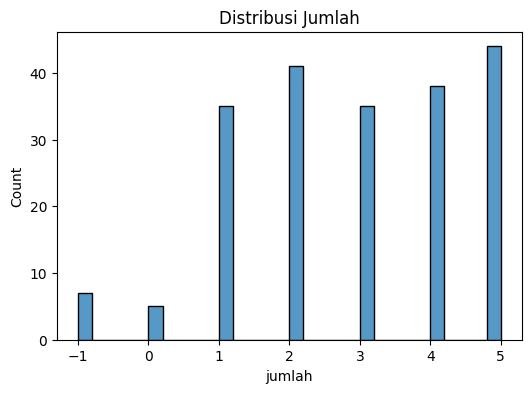

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['jumlah'], bins=30)
plt.title('Distribusi Jumlah')
plt.show()


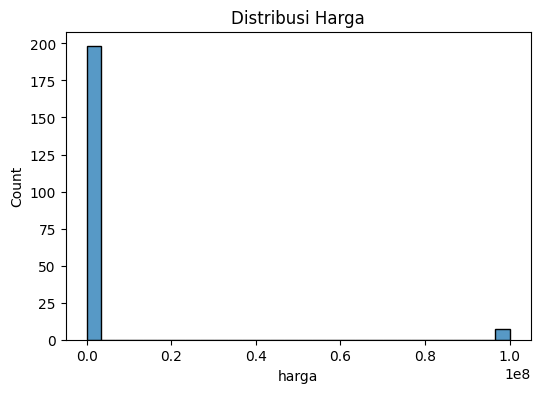

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['harga'], bins=30)
plt.title('Distribusi Harga')
plt.show()


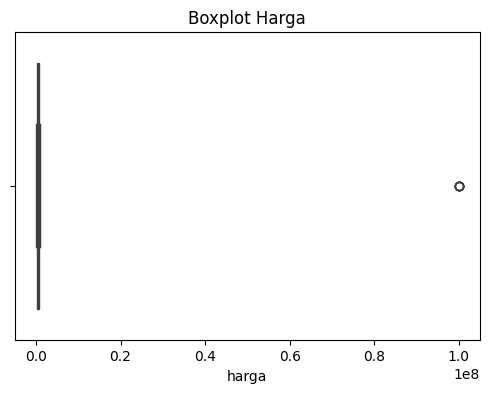

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['harga'])
plt.title('Boxplot Harga')
plt.show()


In [ ]:
total_error = (
    duplikat +
    invalid_jumlah +
    invalid_harga +
    invalid_tanggal +
    len(invalid_email)
)

persen_error = (total_error / total_record) * 100

print(f"{persen_error:.2f}% transaksi bermasalah")


59.51% transaksi bermasalah


In [ ]:
df

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,Fesyen,2023-05-22
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik,2023-05-26
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,Fesyen,2023-05-06
3,5004,C010,P006,2023-05-12,1,834845,user5004,,pending,Fashion,2023-05-12
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,Fesyen,2023-05-26
...,...,...,...,...,...,...,...,...,...,...,...
200,5168,C007,P024,2023-05-24,3,289014,user5168@yahoo.com,39933,pending,Electronics,2023-05-24
201,5024,C029,P010,2023-05-14,2,717844,user5024,16189,pending,elektronik,2023-05-14
202,5200,C015,P030,2023-05-20,5,229641,user5200@gmail.com,68844,pending,Elektronik,2023-05-20
203,5042,C034,P007,2023-05-04,1,76954,user5042@mail.com,72461,cancelled,Electronics,2023-05-04


In [ ]:
df_after_cleaning = df.drop_duplicates(subset='order_id', keep='first')
df_after_cleaning

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,Fesyen,2023-05-22
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik,2023-05-26
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,Fesyen,2023-05-06
3,5004,C010,P006,2023-05-12,1,834845,user5004,,pending,Fashion,2023-05-12
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,Fesyen,2023-05-26
...,...,...,...,...,...,...,...,...,...,...,...
195,5196,C003,P015,2023-02-31,4,308492,user5196,,paid,Elektronik,NaT
196,5197,C025,P025,2023-05-20,4,22670,user5197@yahoo.com,46832,pending,Fashion,2023-05-20
197,5198,C018,P016,2023-05-29,4,592188,user5198@yahoo.com,4012a,paid,Electronics,2023-05-29
198,5199,C002,P015,2023-05-04,4,489632,user5199@gmail.com,12072,cancelled,Fashion,2023-05-04


In [ ]:
df_after_cleaning['kategori'] = df_after_cleaning['kategori'].str.lower()
df_after_cleaning['kategori'] = df_after_cleaning['kategori'].replace('fesyen','fashion').replace('elektronics','elektronik').replace('electronics','elektronik')
df_after_cleaning

/tmp/ipython-input-72996203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['kategori'] = df_after_cleaning['kategori'].str.lower()
/tmp/ipython-input-72996203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['kategori'] = df_after_cleaning['kategori'].replace('fesyen','fashion').replace('elektronics','elektronik').replace('electronics','elektronik')


,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,fashion,2023-05-22
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik,2023-05-26
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,fashion,2023-05-06
3,5004,C010,P006,2023-05-12,1,834845,user5004,,pending,fashion,2023-05-12
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,fashion,2023-05-26
...,...,...,...,...,...,...,...,...,...,...,...
195,5196,C003,P015,2023-02-31,4,308492,user5196,,paid,elektronik,NaT
196,5197,C025,P025,2023-05-20,4,22670,user5197@yahoo.com,46832,pending,fashion,2023-05-20
197,5198,C018,P016,2023-05-29,4,592188,user5198@yahoo.com,4012a,paid,elektronik,2023-05-29
198,5199,C002,P015,2023-05-04,4,489632,user5199@gmail.com,12072,cancelled,fashion,2023-05-04


In [ ]:
import numpy as np

df_after_cleaning['kode_pos'] = (df_after_cleaning['kode_pos'].replace(r'^\s*$',np.nan, regex =True))

/tmp/ipython-input-3248464041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['kode_pos'] = (df_after_cleaning['kode_pos'].replace(r'^\s*$',np.nan, regex =True))


In [ ]:
jumlah_missing_before_cleaning = df_after_cleaning['kode_pos'].isna().sum()

In [ ]:
default_kodepos = 00000
df_after_cleaning['kode_pos'] = df_after_cleaning['kode_pos'].fillna(default_kodepos)
df_after_cleaning


/tmp/ipython-input-2341304061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['kode_pos'] = df_after_cleaning['kode_pos'].fillna(default_kodepos)


,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed
0,5001,C040,P029,2023-05-22,4,663315,user5001@yahoo.com,42146,cancelled,fashion,2023-05-22
1,5002,C021,P024,2023-05-26,2,414214,user5002@gmail.com,28113,paid,elektronik,2023-05-26
2,5003,C032,P016,2023-05-06,4,196494,user5003@gmail.com,15492,paid,fashion,2023-05-06
3,5004,C010,P006,2023-05-12,1,834845,user5004,0,pending,fashion,2023-05-12
4,5005,C029,P027,2023-05-26,0,814730,user5005@yahoo.com,16712,cancelled,fashion,2023-05-26
...,...,...,...,...,...,...,...,...,...,...,...
195,5196,C003,P015,2023-02-31,4,308492,user5196,0,paid,elektronik,NaT
196,5197,C025,P025,2023-05-20,4,22670,user5197@yahoo.com,46832,pending,fashion,2023-05-20
197,5198,C018,P016,2023-05-29,4,592188,user5198@yahoo.com,4012a,paid,elektronik,2023-05-29
198,5199,C002,P015,2023-05-04,4,489632,user5199@gmail.com,12072,cancelled,fashion,2023-05-04


In [ ]:
df_after_cleaning['kode_pos'].isna().sum()

np.int64(0)

In [ ]:
df_after_cleaning['kategori'].unique()

array(['fashion', 'elektronik'], dtype=object)

In [ ]:
print(f"Jumlah baris sebelum cleaning = {len(df)} row\nJumlah baris setelah cleaning = {len(df_after_cleaning)} row")

Jumlah baris sebelum cleaning = 205 row
Jumlah baris setelah cleaning = 200 row


In [ ]:
df_after_cleaning.to_csv('orders_clean.csv', index=False)

In [ ]:
print(f"CONTOH DATA SEBELUM CLEANING\n")
print(df.head(5))


CONTOH DATA SEBELUM CLEANING

   order_id customer_id product_id     tanggal  jumlah   harga  \
0      5001        C040       P029  2023-05-22       4  663315   
1      5002        C021       P024  2023-05-26       2  414214   
2      5003        C032       P016  2023-05-06       4  196494   
3      5004        C010       P006  2023-05-12       1  834845   
4      5005        C029       P027  2023-05-26       0  814730   

                email kode_pos     status    kategori tanggal_parsed  
0  user5001@yahoo.com    42146  cancelled      Fesyen     2023-05-22  
1  user5002@gmail.com    28113       paid  elektronik     2023-05-26  
2  user5003@gmail.com    15492       paid      Fesyen     2023-05-06  
3            user5004             pending     Fashion     2023-05-12  
4  user5005@yahoo.com    16712  cancelled      Fesyen     2023-05-26  


In [ ]:
print(f"CONTOH DATA SESUDAH CLEANING\n")
print(df_after_cleaning.head(5))

CONTOH DATA SESUDAH CLEANING

   order_id customer_id product_id     tanggal  jumlah   harga  \
0      5001        C040       P029  2023-05-22       4  663315   
1      5002        C021       P024  2023-05-26       2  414214   
2      5003        C032       P016  2023-05-06       4  196494   
3      5004        C010       P006  2023-05-12       1  834845   
4      5005        C029       P027  2023-05-26       0  814730   

                email kode_pos     status    kategori tanggal_parsed  
0  user5001@yahoo.com    42146  cancelled     fashion     2023-05-22  
1  user5002@gmail.com    28113       paid  elektronik     2023-05-26  
2  user5003@gmail.com    15492       paid     fashion     2023-05-06  
3            user5004        0    pending     fashion     2023-05-12  
4  user5005@yahoo.com    16712  cancelled     fashion     2023-05-26  


In [ ]:
print(f"Jumlah Data Duplikat yang dihapus = {len(df) - len(df_after_cleaning)}\nJumlah missing yang diisi = {len(df_after_cleaning.loc[df_after_cleaning['kode_pos'] == 0])}")

Jumlah Data Duplikat yang dihapus = 5
Jumlah missing yang diisi = 16


In [ ]:
df_after_cleaning['kode_pos'].isna().sum()

np.int64(0)

In [ ]:
import re

invalid_order_id_null = df_after_cleaning['order_id'].isna()
invalid_order_id_dup = df_after_cleaning['order_id'].duplicated()
invalid_customer = df_after_cleaning['customer_id'].isna()
invalid_product = df_after_cleaning['product_id'].isna()
invalid_jumlah = ((df_after_cleaning['jumlah'] < 0 | (df_after_cleaning['jumlah'] > 100 | (df_after_cleaning['jumlah'].isna()))))
invalid_harga = ((df_after_cleaning['harga'] < 100 | (df_after_cleaning['harga'] > 10_000_000 | (df_after_cleaning['harga'].isna()))))

email_pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
invalid_email = ~df_after_cleaning['email'].str.match(email_pattern, na = False)

df_after_cleaning['tanggal_parsed'] = pd.to_datetime(df_after_cleaning['tanggal'], errors = 'coerce')
invalid_tanggal = df_after_cleaning['tanggal_parsed'].isna()

valid_status = ['paid', 'pending', 'cancelled']
invalid_status = ~df_after_cleaning['status'].isin(valid_status)




/tmp/ipython-input-3555786036.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['tanggal_parsed'] = pd.to_datetime(df_after_cleaning['tanggal'], errors = 'coerce')


In [ ]:
df_after_cleaning['is_invalid'] = (
    invalid_order_id_null |
    invalid_order_id_dup |
    invalid_customer |
    invalid_product |
    invalid_jumlah |
    invalid_harga |
    invalid_email |
    invalid_tanggal |
    invalid_status
)

/tmp/ipython-input-3120486418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_cleaning['is_invalid'] = (


In [ ]:
total_rows = len(df_after_cleaning)
invalid_rows = df_after_cleaning['is_invalid'].sum()
valid_rows = total_rows - invalid_rows

print(f"Total data : {total_rows}\nLolos : {valid_rows}\nGagal : {invalid_rows}")

Total data : 200
Lolos : 110
Gagal : 90


In [ ]:
df_invalid = df_after_cleaning.loc[df_after_cleaning['is_invalid']].head(5)

df_invalid

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori,tanggal_parsed,is_invalid
3,5004,C010,P006,2023-05-12,1,834845,user5004,0,pending,fashion,2023-05-12,True
5,5006,C017,P012,06/05/2023,5,440492,,4012a,paid,elektronik,NaT,True
6,5007,C004,P002,2023-05-15,2,543696,user5007,67283,paid,elektronik,2023-05-15,True
10,5011,C024,P002,2023-05-06,3,0,user5011@mail.com,0,paid,elektronik,2023-05-06,True
11,5012,C045,P020,2023-05-18,1,64998,user5012,94222,pending,fashion,2023-05-18,True


In [ ]:
# Validasi dilakukan untuk memastikan data sesuai aturan skema.
# Pengecekan mencakup keunikan ID, range nilai, format email & tanggal, serta status.
# Dari total 200 data, sebanyak 110 valid dan 90 invalid.
# Data yang gagal perlu dibersihkan sebelum diproses lebih lanjut.